In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use(hep.style.ROOT)

In [3]:
def load_and_average(file_prefix, num_files=5):
    dataframes = []
    for i in range(1, num_files + 1):
        filename = f"{file_prefix}_{i}.csv"
        df = pd.read_csv(filename) 
        dataframes.append(df['Intensity'])
    
    avg_intensity = pd.concat(dataframes, axis=1).mean(axis=1)
    
    result_df = pd.DataFrame({
        'Step_Number': pd.read_csv(f"{file_prefix}_1.csv")['Step_Number'],
        'Intensity': avg_intensity
    })
    return result_df

df_air = load_and_average('air')
df_sample = load_and_average('greenObject')

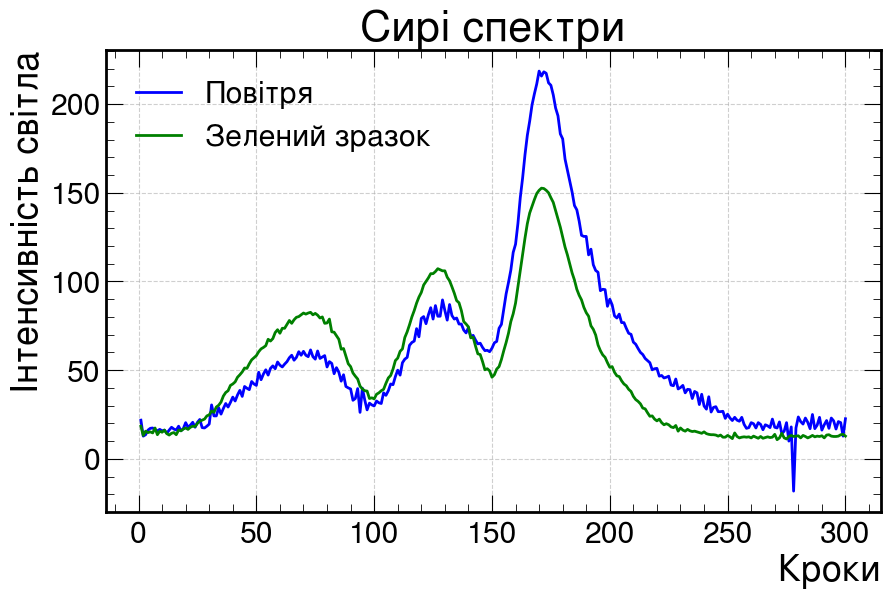

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(df_air['Step_Number'], df_air['Intensity'], label='Повітря', color='blue', linewidth=2)
plt.plot(df_sample['Step_Number'], df_sample['Intensity'], label='Зелений зразок', color='green', linewidth=2)

plt.title('Сирі спектри')
plt.xlabel('Кроки')
plt.ylabel('Інтенсивність світла')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

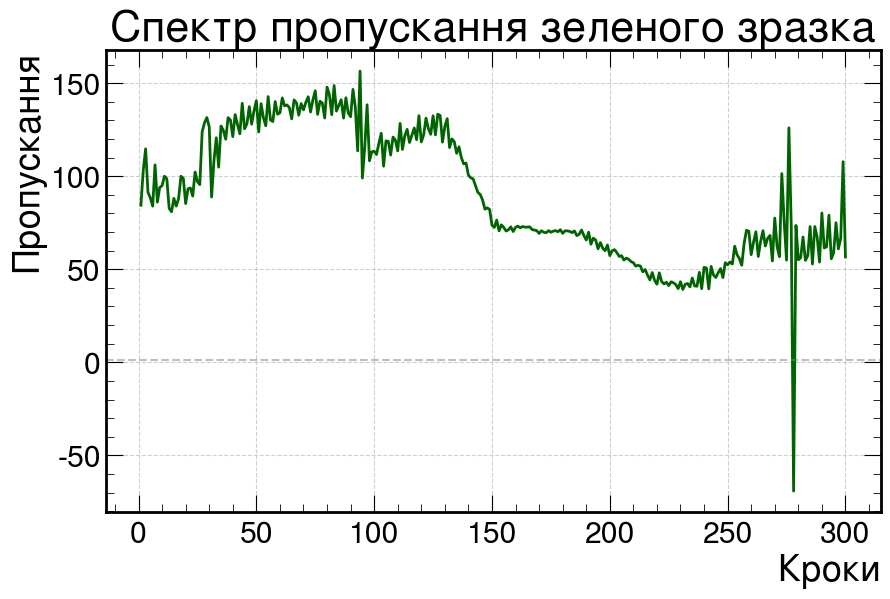

In [5]:
transmittance = df_sample['Intensity'] / df_air['Intensity']

plt.figure(figsize=(10, 6))

plt.plot(df_sample['Step_Number'], transmittance*100, color='darkgreen', linewidth=2)

plt.title('Спектр пропускання зеленого зразка')
plt.xlabel('Кроки')
plt.ylabel('Пропускання')
plt.axhline(1, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

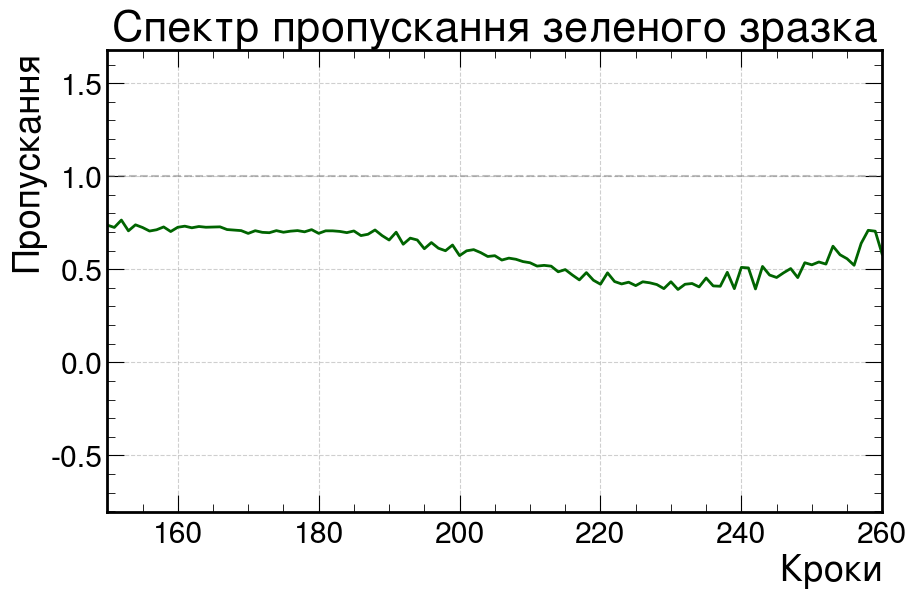

In [6]:
transmittance = df_sample['Intensity'] / df_air['Intensity']

plt.figure(figsize=(10, 6))

plt.plot(df_sample['Step_Number'], transmittance, color='darkgreen', linewidth=2)

plt.title('Спектр пропускання зеленого зразка')
plt.xlabel('Кроки')
plt.ylabel('Пропускання')
plt.xlim(150, 260)
plt.axhline(1, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

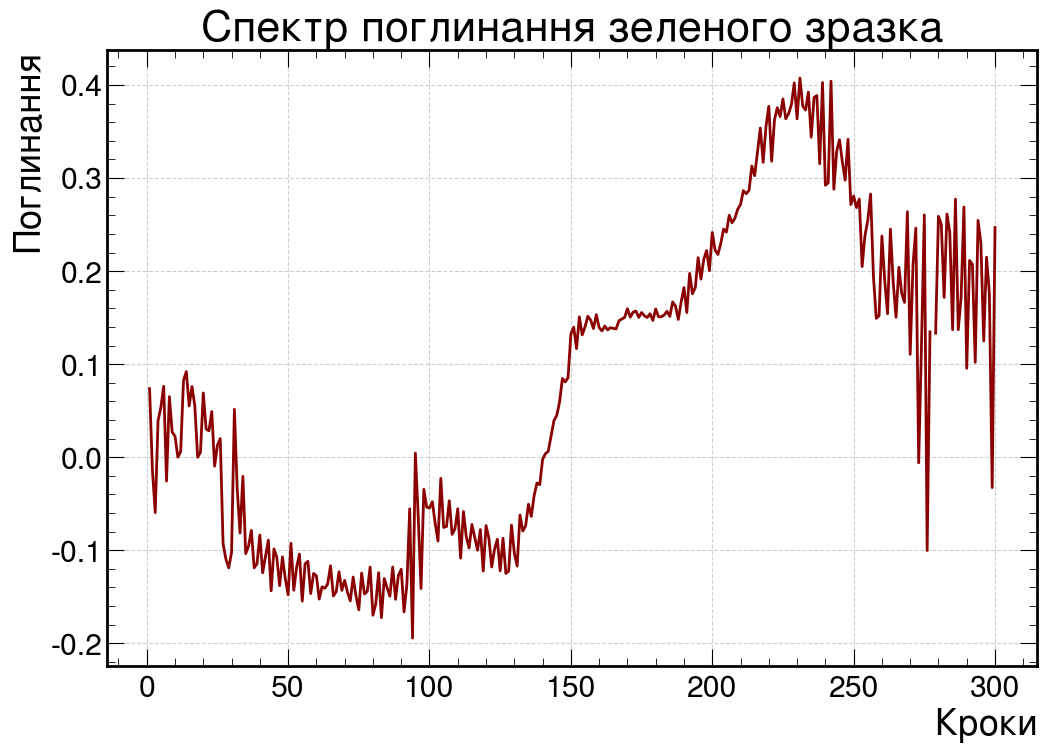

In [10]:
transmittance = df_sample['Intensity'] / df_air['Intensity']

absorbance = -np.log10(transmittance)

plt.figure(figsize=(12, 8))

plt.plot(df_sample['Step_Number'], absorbance, color='darkred', linewidth=2)

plt.title('Спектр поглинання зеленого зразка')
plt.xlabel('Кроки')
plt.ylabel('Поглинання')

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

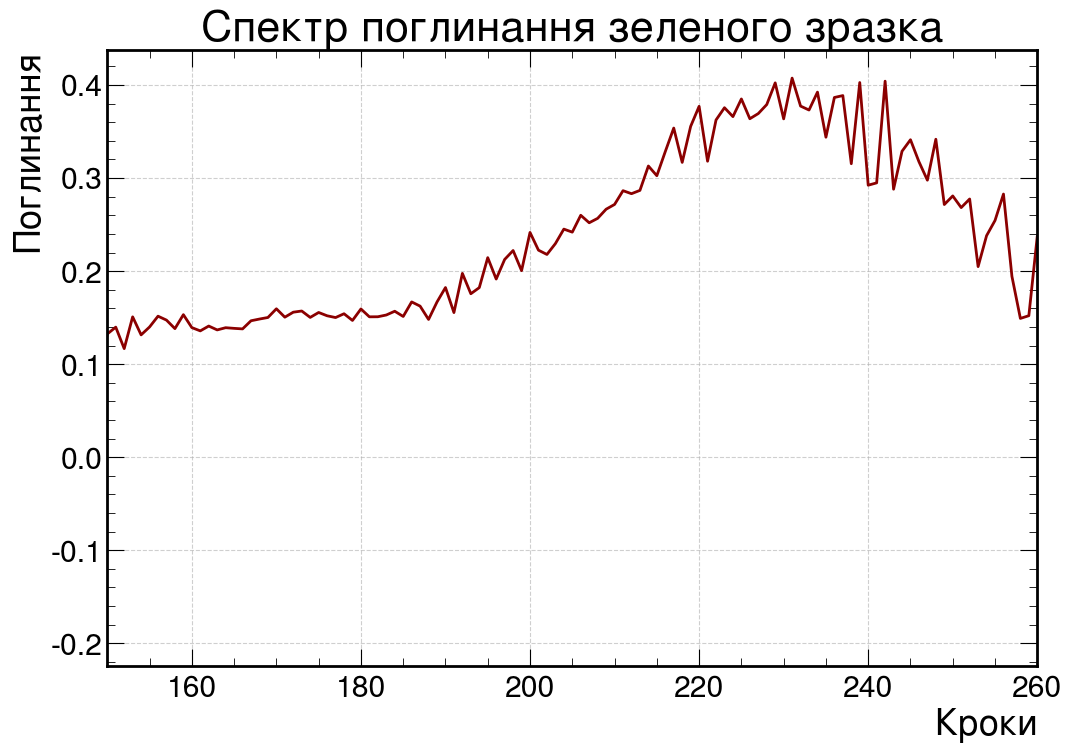

In [11]:
transmittance = df_sample['Intensity'] / df_air['Intensity']

absorbance = -np.log10(transmittance)

plt.figure(figsize=(12, 8))

plt.plot(df_sample['Step_Number'], absorbance, color='darkred', linewidth=2)

plt.title('Спектр поглинання зеленого зразка')
plt.xlabel('Кроки')
plt.ylabel('Поглинання')

plt.xlim(150, 260)

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()